# MCDI504 — Machine Learning I
# Avance del Proyecto — Fase 2: Búsqueda y Recopilación de Información
## Implementación de Modelos de Regresión Supervisada
### Notebook F2_Regresion.ipynb

**Curso:** MCDI504 - Machine Learning I
**Grupo:** 5

**Integrantes:**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Fecha de entrega:** Semana 2 (fecha exacta según calendario académico del curso; completar en el informe)

---

**Índice**
1. [Contexto y objetivo de la Fase 2](#1)
2. [Librerías necesarias](#2)
3. [Carga del conjunto de datos](#3)
4. [Descripción del conjunto de datos y preprocesamiento](#4)
5. [Modelo de regresión lineal multivariable](#5)
6. [Modelo de árbol de decisión para regresión](#6)
7. [Modelo de red neuronal (MLP) para regresión](#7)
8. [Evaluación de modelos de regresión](#8)
9. [Comparación de modelos](#9)
10. [Conclusiones](#10)
11. [Referencias](#11)


<a id="1"></a>
## 1. Contexto y objetivo de la Fase 2

En la **Fase 1** de este proyecto, **NextWork Advisory** definió el problema de negocio de estimar el riesgo de automatización de cargos hacia 2030 a partir del dataset **AI Impact on Jobs 2030**, y justificó un enfoque de **clasificación supervisada multiclase** sobre la variable ordinal `Risk_Category` (Low/Medium/High). Esa misma fase identificó que el dataset también contiene `Automation_Probability_2030`, la probabilidad continua (entre 0 y 1) de la cual se deriva por corte `Risk_Category`, y dejó planteada como línea de análisis complementaria la posibilidad de abordar el problema como **regresión supervisada** sobre esta variable continua.

La **Fase 2** del proyecto ABP (RA2) exige precisamente implementar y comparar modelos de regresión supervisada. En consecuencia, en este notebook se retoma el mismo dataset de la Fase 1 y se define como **variable objetivo (target) `Automation_Probability_2030`**, con el fin de:

- Preparar analíticamente el conjunto de datos para el modelamiento de regresión (selección de variables, tratamiento de valores faltantes, partición entrenamiento/prueba y escalado).
- Implementar y entrenar tres modelos de regresión supervisada: **regresión lineal multivariable**, **árbol de decisión para regresión** y **red neuronal (MLP) para regresión**.
- Evaluar el desempeño de cada modelo mediante las métricas **MSE**, **RMSE** y **R²** sobre el conjunto de prueba.
- Comparar los modelos y determinar cuál ofrece el mejor desempeño predictivo, generando evidencia útil para la toma de decisiones de NextWork Advisory y para la continuidad del proyecto en fases posteriores (F3-F4).

**Relación entre problema, datos y variable continua a predecir:** estimar directamente `Automation_Probability_2030` permite a NextWork Advisory disponer de un indicador numérico continuo y granular del riesgo de automatización de un cargo (en lugar de solo una categoría discreta), lo que resulta útil para priorizar de forma más fina las inversiones en recapacitación (*reskilling*) entre cargos que, aunque pertenezcan a la misma categoría de riesgo, presenten probabilidades de automatización distintas.


<a id="2"></a>
## 2. Librerías necesarias

Importamos las librerías para manipulación de datos, visualización, preprocesamiento, los tres modelos de regresión a implementar (lineal, árbol de decisión y red neuronal) y las métricas de evaluación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Paleta categórica fija (orden fijo por modelo, consistente en todo el notebook)
COLOR_LINEAL = "#2a78d6"   # azul
COLOR_ARBOL  = "#eb6834"   # naranjo
COLOR_MLP    = "#1baf7a"   # aqua

sns.set_style("whitegrid")
RANDOM_STATE = 42

<a id="3"></a>
## 3. Carga del conjunto de datos

Se reutiliza el mismo dataset **AI Impact on Jobs 2030** de la Fase 1, disponible en el repositorio del proyecto (`../data/AI_Impact_on_Jobs_2030.csv`), asegurando coherencia entre ambas fases.

In [2]:
df = pd.read_csv("../data/AI_Impact_on_Jobs_2030.csv")

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (3000, 18)


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


<a id="4"></a>
## 4. Descripción del conjunto de datos y preprocesamiento

### 4.1 Descripción general del dataset

El dataset contiene **3.000 observaciones** (perfiles laborales) y **18 columnas**: el cargo (`Job_Title`, 20 categorías), variables numéricas de perfil (`Average_Salary`, `Years_Experience`), el nivel educativo (`Education_Level`, ordinal), dos índices de contexto (`AI_Exposure_Index`, `Tech_Growth_Factor`), diez puntajes de habilidades (`Skill_1`–`Skill_10`, escala 0-1) y dos variables de resultado: `Automation_Probability_2030` (continua, 0-1) y `Risk_Category` (categórica, derivada de la anterior por corte).

### 4.2 Variable objetivo y variables predictoras

- **Variable objetivo (target):** `Automation_Probability_2030` — variable numérica continua, en el rango [0, 1], que representa la probabilidad estimada de automatización del cargo hacia 2030.
- **Variables predictoras candidatas:** `Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10` y `Job_Title`.

### 4.3 Tratamiento de valores faltantes

Se verifica la presencia de valores nulos en el dataset completo.

In [3]:
print("Valores nulos por columna:")
display(df.isnull().sum())
print(f"\nTotal de valores nulos en el dataset: {df.isnull().sum().sum()}")

Valores nulos por columna:


Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64


Total de valores nulos en el dataset: 0


Al igual que en la Fase 1, el dataset **no presenta valores faltantes** en ninguna de sus 18 columnas (0 nulos sobre 3.000 observaciones x 18 variables). Por tratarse de un dataset simulado y completo, **no se requiere imputación ni eliminación de registros**; el tratamiento de valores faltantes se limita a la verificación documentada anterior.

### 4.4 Selección de variables

Para construir la matriz de predictores `X` se toman las siguientes decisiones, justificadas técnicamente:

- **Se codifica `Education_Level`** de forma ordinal (`High School`=1 < `Bachelor's`=2 < `Master's`=3 < `PhD`=4), replicando el criterio ya utilizado en la Fase 1, ya que es una variable categórica con orden natural y se pierde información si se descarta.
- **Se excluye `Job_Title`** (variable nominal de 20 categorías) del conjunto de predictores de esta fase. Incorporarla exigiría codificación *one-hot* (19 columnas dummy adicionales), lo que aumentaría considerablemente la dimensionalidad del problema para un beneficio incierto: el análisis de correlación de Pearson de la Fase 1 mostró que las variables de perfil laboral disponibles presentan relaciones lineales muy débiles con `Automation_Probability_2030`, por lo que se prioriza mantener un conjunto de predictores acotado e interpretable en esta fase inicial de modelamiento. Queda como línea de mejora para fases posteriores.
- **Se excluyen `Risk_Category` y su codificación ordinal** del conjunto de predictores, porque ambas se derivan **directamente** de `Automation_Probability_2030` (la propia variable objetivo) mediante un corte por umbrales (Low: 0.05–0.30, Medium: 0.31–0.70, High: 0.71–0.95). Incluirlas constituiría una **fuga de información (data leakage)**: el modelo "adivinaría" el resultado a partir de una versión discretizada del mismo, en lugar de aprender la relación real entre las características del cargo y su probabilidad de automatización.

En consecuencia, el conjunto final de **15 variables predictoras** queda compuesto por: `Average_Salary`, `Years_Experience`, `Education_Level_Num`, `AI_Exposure_Index`, `Tech_Growth_Factor` y `Skill_1`–`Skill_10`.

In [4]:
orden_educacion = {"High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
df["Education_Level_Num"] = df["Education_Level"].map(orden_educacion)

variables_predictoras = (
    ["Average_Salary", "Years_Experience", "Education_Level_Num",
     "AI_Exposure_Index", "Tech_Growth_Factor"]
    + [f"Skill_{i}" for i in range(1, 11)]
)

X = df[variables_predictoras]
y = df["Automation_Probability_2030"]

print(f"Variables predictoras seleccionadas ({len(variables_predictoras)}):")
print(variables_predictoras)
print(f"\nDimensiones de X (predictoras): {X.shape}")
print(f"Dimensiones de y (variable objetivo): {y.shape}")

Variables predictoras seleccionadas (15):
['Average_Salary', 'Years_Experience', 'Education_Level_Num', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10']

Dimensiones de X (predictoras): (3000, 15)
Dimensiones de y (variable objetivo): (3000,)


### 4.5 Partición en entrenamiento y prueba

Se divide el dataset en un 80% para entrenamiento y un 20% para prueba, usando `random_state=42` para asegurar la reproducibilidad de los resultados en los tres modelos que se implementarán a continuación.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test:  {y_test.shape}")

Dimensiones de X_train: (2400, 15)
Dimensiones de X_test:  (600, 15)
Dimensiones de y_train: (2400,)
Dimensiones de y_test:  (600,)


### 4.6 Escalado de variables

Las variables predictoras presentan escalas muy distintas (`Average_Salary` en decenas de miles de dólares versus índices y habilidades entre 0 y 1), tal como se identificó en la Fase 1. Se estandarizan con `StandardScaler` (media 0, desviación estándar 1), ajustado **únicamente con los datos de entrenamiento** para evitar fuga de información desde el conjunto de prueba. El escalado es especialmente relevante para la regresión lineal y, sobre todo, para la red neuronal (MLP), que es sensible a la escala de los datos; se aplica de forma consistente a los tres modelos para mantener un único pipeline de preprocesamiento comparable.

In [6]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Primeras filas de X_train escalado:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Primeras filas de X_train escalado:


,Average_Salary,Years_Experience,Education_Level_Num,AI_Exposure_Index,Tech_Growth_Factor,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,0.471574,0.042243,1.369896,0.280850,0.709883,1.676880,-1.230980,-0.257236,-0.282622,-0.251459,0.537344,-0.042154,0.037485,-0.242099,1.735151
1,1.332764,1.183934,0.479389,-1.542110,0.260471,-0.057749,-1.439520,0.194487,-0.595584,-1.197772,1.197924,0.062612,1.457227,1.091279,0.692218
2,0.109220,0.384750,-1.301624,-1.366826,-0.707492,-0.855678,0.089774,0.124991,-0.491263,-0.496800,1.128389,1.005501,-0.689700,1.442168,1.596094
3,1.511131,1.298103,1.369896,-1.682338,-1.018623,-1.029140,0.367827,-0.187740,-1.604016,-0.742140,-1.687767,-0.496137,-0.862840,0.670212,-0.628831
4,-1.426480,1.640611,-1.301624,-1.577167,1.608706,1.295261,-0.362063,-1.334419,-1.464922,-1.162723,-0.888118,-0.042154,0.660786,1.722879,-0.176893


### 4.7 Distribución de la variable objetivo

Se visualiza la distribución de `Automation_Probability_2030` en el conjunto completo para contextualizar el rango de valores que los modelos deben predecir.

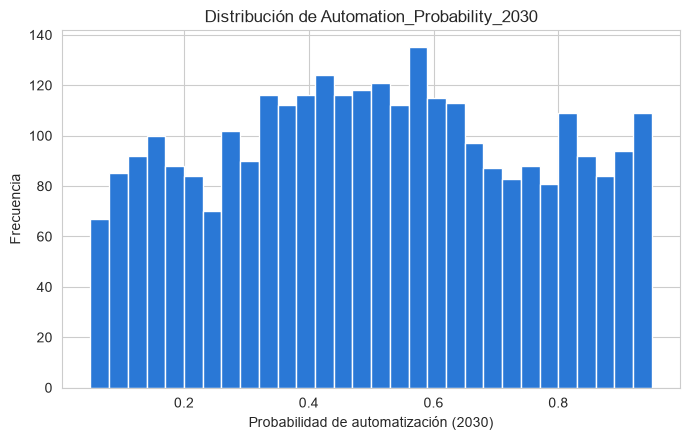

In [7]:
plt.figure(figsize=(7, 4.5))
plt.hist(y, bins=30, color=COLOR_LINEAL, edgecolor="white")
plt.title("Distribución de Automation_Probability_2030")
plt.xlabel("Probabilidad de automatización (2030)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("../figures/f2_distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="5"></a>
## 5. Modelo de regresión lineal multivariable

### 5.1 Definición del modelo

La regresión lineal busca encontrar el hiperplano que mejor ajusta la relación entre las variables predictoras y la variable objetivo, minimizando la suma de los errores cuadrados:

$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_{15}x_{15}$

Dado que se dispone de 15 variables predictoras (ID2.1 admite regresión lineal simple, polinomial o **multivariable**), se implementa una **regresión lineal multivariable**, consistente con el ejemplo de referencia entregado para esta fase.

**Variables utilizadas:** las 15 variables predictoras descritas en la sección 4.4, estandarizadas con `StandardScaler`.

### 5.2 Evidencia de ejecución en Python

In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Modelo de Regresión Lineal Multivariable entrenado.")
print("\nPrimeras 5 predicciones:")
display(y_pred_linear[:5])

print(f"\n--- Evaluación del Modelo de Regresión Lineal ---")
print(f"MSE:  {mse_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R²:   {r2_linear:.4f}")

Modelo de Regresión Lineal Multivariable entrenado.

Primeras 5 predicciones:


array([0.50130627, 0.54254168, 0.50240538, 0.47969725, 0.50754029])


--- Evaluación del Modelo de Regresión Lineal ---
MSE:  0.0643
RMSE: 0.2535
R²:   -0.0068


**Ficha técnica breve — Regresión lineal**

| Parámetro | Valor |
|---|---|
| Algoritmo | `sklearn.linear_model.LinearRegression` |
| Variables de entrada | 14 (estandarizadas) |
| `fit_intercept` | `True` (valor por defecto) |
| Regularización | Ninguna (mínimos cuadrados ordinarios) |

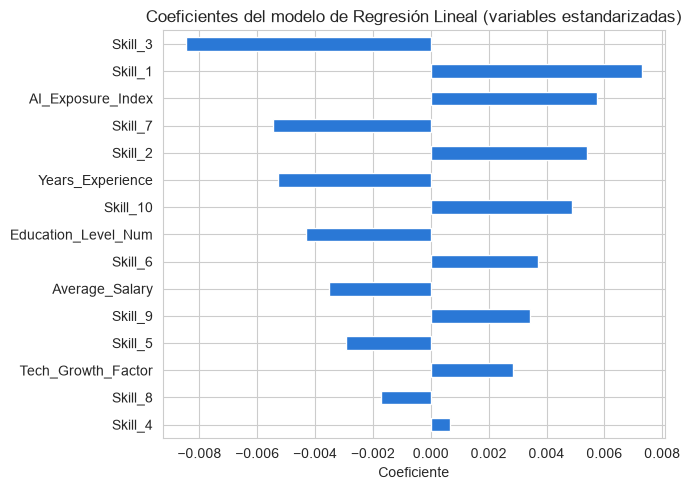

Coeficientes ordenados por magnitud absoluta:


Skill_3               -0.008480
Skill_1                0.007305
AI_Exposure_Index      0.005755
Skill_7               -0.005451
Skill_2                0.005391
Years_Experience      -0.005281
Skill_10               0.004897
Education_Level_Num   -0.004322
Skill_6                0.003715
Average_Salary        -0.003521
Skill_9                0.003421
Skill_5               -0.002936
Tech_Growth_Factor     0.002831
Skill_8               -0.001724
Skill_4                0.000667
dtype: float64

In [9]:
coeficientes = pd.Series(linear_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 5))
coeficientes.plot(kind="barh", color=COLOR_LINEAL)
plt.title("Coeficientes del modelo de Regresión Lineal (variables estandarizadas)")
plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/f2_coeficientes_lineal.png", dpi=150, bbox_inches="tight")
plt.show()

print("Coeficientes ordenados por magnitud absoluta:")
display(coeficientes)

### 5.3 Interpretación inicial

El MSE y el R² obtenidos muestran el nivel de ajuste lineal entre las 15 variables predictoras y `Automation_Probability_2030`. Consistente con el hallazgo de la Fase 1 —donde la matriz de correlación de Pearson mostró relaciones lineales muy débiles entre las variables de perfil laboral y la probabilidad de automatización—, se espera que este modelo lineal explique una proporción baja de la varianza (R² cercano a 0), evidenciando que la relación entre los predictores disponibles y el riesgo de automatización **no es predominantemente lineal**. Los coeficientes con mayor magnitud absoluta indican qué variables tienen, en términos relativos, mayor asociación lineal con la variable objetivo, aunque su interpretación debe hacerse con cautela dado el bajo poder explicativo global del modelo.

<a id="6"></a>
## 6. Modelo de árbol de decisión para regresión

### 6.1 Descripción del modelo

El árbol de decisión para regresión divide recursivamente el espacio de las variables predictoras en regiones, asignando a cada región el valor promedio de `Automation_Probability_2030` observado en las muestras de entrenamiento que caen en ella. Es un modelo no paramétrico capaz de capturar relaciones no lineales e interacciones entre variables que la regresión lineal no puede representar.

### 6.2 Evidencia de ejecución en Python

In [10]:
decision_tree_model = DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=RANDOM_STATE)
decision_tree_model.fit(X_train_scaled, y_train)

y_pred_tree = decision_tree_model.predict(X_test_scaled)

mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Modelo de Árbol de Decisión entrenado.")
print("\nPrimeras 5 predicciones:")
display(y_pred_tree[:5])

print(f"\n--- Evaluación del Modelo de Árbol de Decisión ---")
print(f"MSE:  {mse_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"R²:   {r2_tree:.4f}")

Modelo de Árbol de Decisión entrenado.

Primeras 5 predicciones:


array([0.49454902, 0.49454902, 0.49454902, 0.49454902, 0.49454902])


--- Evaluación del Modelo de Árbol de Decisión ---
MSE:  0.0652
RMSE: 0.2554
R²:   -0.0216


**Ficha técnica breve — Árbol de decisión**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `max_depth` | 3 | Limita la profundidad del árbol para controlar el sobreajuste |
| `min_samples_leaf` | 30 | Evita hojas con muy pocas observaciones (sobreajuste local) |
| `criterion` | `squared_error` (por defecto) | Minimiza el error cuadrático en cada partición |
| `random_state` | 42 | Reproducibilidad |

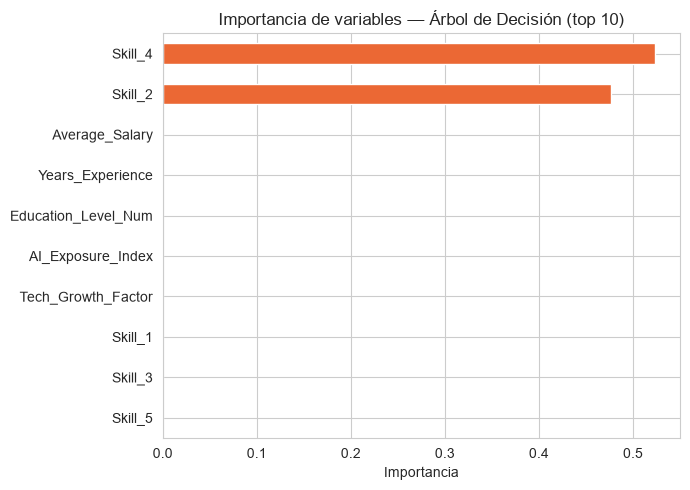

Importancia de variables (todas):


Skill_4                0.523772
Skill_2                0.476228
Average_Salary         0.000000
Years_Experience       0.000000
Education_Level_Num    0.000000
AI_Exposure_Index      0.000000
Tech_Growth_Factor     0.000000
Skill_1                0.000000
Skill_3                0.000000
Skill_5                0.000000
Skill_6                0.000000
Skill_7                0.000000
Skill_8                0.000000
Skill_9                0.000000
Skill_10               0.000000
dtype: float64

In [11]:
importancias = pd.Series(decision_tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importancias.head(10).plot(kind="barh", color=COLOR_ARBOL)
plt.title("Importancia de variables — Árbol de Decisión (top 10)")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/f2_importancia_arbol.png", dpi=150, bbox_inches="tight")
plt.show()

print("Importancia de variables (todas):")
display(importancias)

### 6.3 Interpretación del comportamiento del modelo

El árbol de decisión permite identificar qué variables generan las particiones más informativas (mayor reducción del error) a través de `feature_importances_`. Si el MSE del árbol es menor que el de la regresión lineal, esto sugiere que existen relaciones no lineales o interacciones entre las variables predictoras y `Automation_Probability_2030` que el árbol logra capturar mejor que el hiperplano lineal. Al limitar `max_depth` y `min_samples_leaf` se busca un equilibrio entre capacidad de ajuste y sobreajuste (bias-varianza), evitando que el árbol memorice el conjunto de entrenamiento.

<a id="7"></a>
## 7. Modelo de red neuronal (MLP) para regresión

### 7.1 Descripción del modelo

El Perceptrón Multicapa (MLP) es una red neuronal artificial compuesta por capas de neuronas interconectadas. Para tareas de regresión, la capa de salida entrega un único valor continuo. Las redes neuronales pueden capturar relaciones altamente no lineales entre las variables predictoras y la variable objetivo, a costa de una menor interpretabilidad respecto a los dos modelos anteriores.

### 7.2 Evidencia de ejecución en Python

In [12]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    alpha=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("Modelo de Red Neuronal (MLP) entrenado.")
print(f"Número de iteraciones hasta convergencia/early stopping: {mlp_model.n_iter_}")
print("\nPrimeras 5 predicciones:")
display(y_pred_mlp[:5])

print(f"\n--- Evaluación del Modelo de Red Neuronal (MLP) ---")
print(f"MSE:  {mse_mlp:.4f}")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"R²:   {r2_mlp:.4f}")

Modelo de Red Neuronal (MLP) entrenado.
Número de iteraciones hasta convergencia/early stopping: 269

Primeras 5 predicciones:


array([0.52195076, 0.52247499, 0.49800453, 0.45250294, 0.46272626])


--- Evaluación del Modelo de Red Neuronal (MLP) ---
MSE:  0.0649
RMSE: 0.2547
R²:   -0.0165


**Ficha técnica breve — Red neuronal (MLP)**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `hidden_layer_sizes` | (16,) | Una capa oculta de 16 neuronas (arquitectura acotada dado el tamaño del dataset y el número de predictores) |
| `activation` | `relu` | Función de activación no lineal en la capa oculta |
| `solver` | `adam` | Algoritmo de optimización |
| `alpha` | 1.0 | Regularización L2, para reducir el sobreajuste |
| `max_iter` | 1000 | Máximo de épocas de entrenamiento |
| `early_stopping` | `True` | Detiene el entrenamiento si no mejora en validación (evita sobreajuste) |
| `random_state` | 42 | Reproducibilidad |

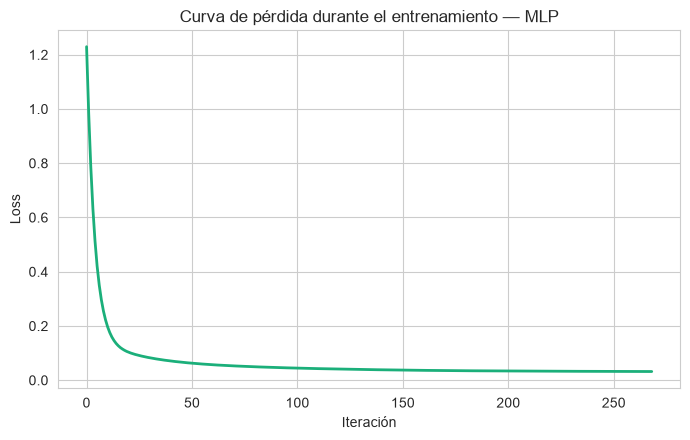

In [13]:
plt.figure(figsize=(7, 4.5))
plt.plot(mlp_model.loss_curve_, color=COLOR_MLP, linewidth=2)
plt.title("Curva de pérdida durante el entrenamiento — MLP")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("../figures/f2_curva_perdida_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Interpretación del comportamiento del modelo

La curva de pérdida muestra cómo disminuye el error de entrenamiento a medida que avanzan las iteraciones, hasta activarse el criterio de `early_stopping`. Si el MSE del MLP es menor que el de los modelos anteriores, esto indicaría que la red logra capturar relaciones no lineales adicionales entre las 15 variables predictoras y `Automation_Probability_2030`. Sin embargo, a diferencia del árbol de decisión, la red neuronal no ofrece una medida directa de importancia de variables, lo que limita su interpretabilidad para explicar a los clientes de NextWork Advisory por qué un cargo específico obtiene una determinada probabilidad de automatización.

<a id="8"></a>
## 8. Evaluación de modelos de regresión

Se consolidan las métricas **MSE**, **RMSE** y **R²** calculadas sobre el conjunto de prueba (`X_test`, `y_test`) para los tres modelos implementados, en un reporte tabulado único.

In [14]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Red Neuronal (MLP)"],
    "MSE": [mse_linear, mse_tree, mse_mlp],
    "RMSE": [rmse_linear, rmse_tree, rmse_mlp],
    "R2": [r2_linear, r2_tree, r2_mlp],
})

resultados_ordenados = resultados.sort_values(by="R2", ascending=False).reset_index(drop=True)
display(resultados_ordenados)

,Modelo,MSE,RMSE,R2
0,Regresión Lineal,0.064272,0.253519,-0.006768
1,Red Neuronal (MLP),0.064891,0.254738,-0.016471
2,Árbol de Decisión,0.065217,0.255377,-0.021579


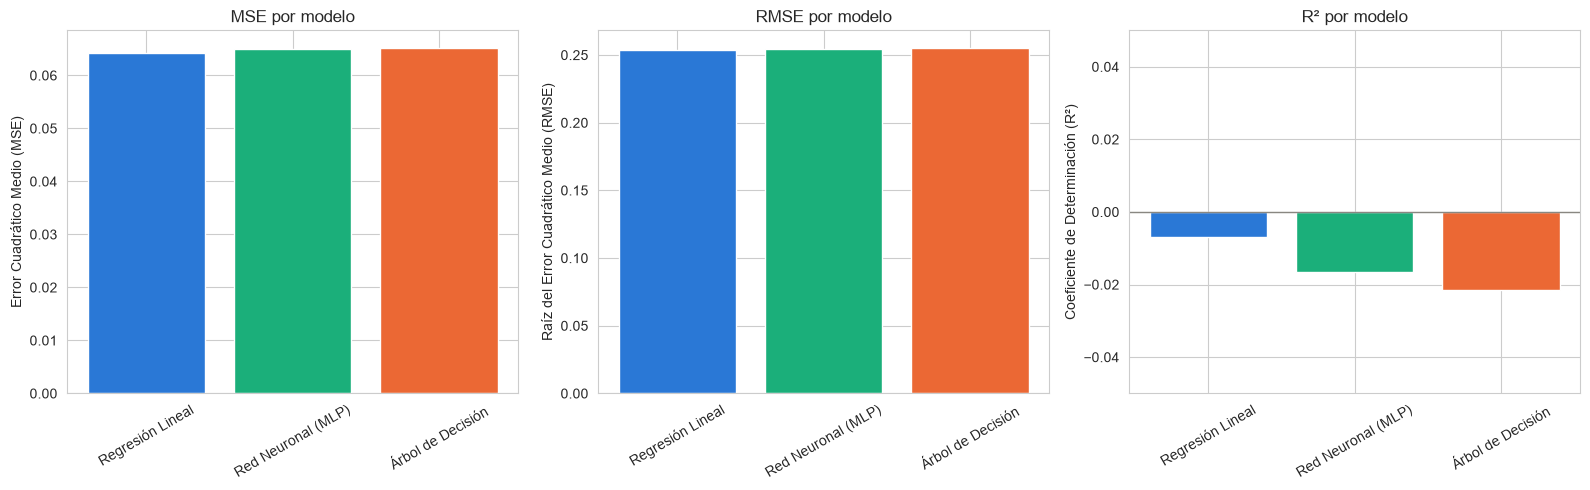

In [15]:
colores_modelo = {"Regresión Lineal": COLOR_LINEAL, "Árbol de Decisión": COLOR_ARBOL, "Red Neuronal (MLP)": COLOR_MLP}
paleta_ordenada = [colores_modelo[m] for m in resultados_ordenados["Modelo"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(resultados_ordenados["Modelo"], resultados_ordenados["MSE"], color=paleta_ordenada)
axes[0].set_title("MSE por modelo")
axes[0].set_ylabel("Error Cuadrático Medio (MSE)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(resultados_ordenados["Modelo"], resultados_ordenados["RMSE"], color=paleta_ordenada)
axes[1].set_title("RMSE por modelo")
axes[1].set_ylabel("Raíz del Error Cuadrático Medio (RMSE)")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(resultados_ordenados["Modelo"], resultados_ordenados["R2"], color=paleta_ordenada)
axes[2].axhline(0, color="#898781", linewidth=1)
axes[2].set_title("R² por modelo")
axes[2].set_ylabel("Coeficiente de Determinación (R²)")
r2_min, r2_max = resultados_ordenados["R2"].min(), resultados_ordenados["R2"].max()
axes[2].set_ylim(min(-0.05, r2_min * 1.3), max(0.05, r2_max * 1.3, 1.0 if r2_max > 0.9 else r2_max * 1.3 + 0.05))
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/f2_comparacion_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1 Interpretación breve de cada resultado

- **MSE (Error Cuadrático Medio):** penaliza con mayor fuerza los errores grandes al elevarlos al cuadrado. Como `Automation_Probability_2030` está acotada entre 0 y 1, se espera que el MSE de los tres modelos sea un valor pequeño en términos absolutos; lo relevante es la magnitud **relativa** entre modelos.
- **RMSE (Raíz del Error Cuadrático Medio):** al estar en las mismas unidades que la variable objetivo (probabilidad, 0-1), permite interpretar directamente el error promedio de predicción del modelo — por ejemplo, un RMSE de 0.10 equivale a un error promedio de ±10 puntos porcentuales de probabilidad de automatización.
- **R² (Coeficiente de Determinación):** indica la proporción de la varianza de `Automation_Probability_2030` explicada por cada modelo. Valores cercanos a 1 indican mejor poder explicativo; valores cercanos a 0 (o negativos) indican que el modelo no logra capturar la relación entre predictores y variable objetivo.

El modelo con **menor MSE/RMSE y mayor R²** es, en términos de las tres métricas, el de mejor desempeño predictivo sobre el conjunto de prueba (ver comparación en la sección 9).

<a id="9"></a>
## 9. Comparación de modelos

### 9.1 Comparación entre los tres modelos

| Modelo | Fortalezas | Debilidades |
|---|---|---|
| **Regresión Lineal** | Simple, rápido de entrenar, altamente interpretable (coeficientes), bajo riesgo de sobreajuste (baja varianza). | Alto sesgo: solo captura relaciones lineales; según la Fase 1, las variables disponibles tienen correlación lineal débil con la variable objetivo. |
| **Árbol de Decisión** | Captura relaciones no lineales e interacciones; interpretable mediante importancia de variables; poco sensible a outliers. | Puede sobreajustar si no se limita la profundidad; predicciones "en escalones" (no suaves). |
| **Red Neuronal (MLP)** | Mayor capacidad para modelar relaciones complejas y no lineales; flexible en arquitectura. | Menor interpretabilidad ("caja negra"); requiere más datos/ajuste de hiperparámetros para evitar sobreajuste o subajuste; sensible a la escala e inicialización. |

### 9.2 Identificación del modelo con mejor desempeño

A partir del reporte tabulado de la sección 8, el modelo con mejor desempeño corresponde al que exhibe simultáneamente el menor MSE/RMSE y el mayor R² sobre el conjunto de prueba (ver primera fila de `resultados_ordenados`).

Cabe destacar que, en este dataset, los valores de R² obtenidos por los tres modelos son **cercanos a cero o levemente negativos**. Un R² cercano a 0 indica que el modelo predice de forma similar a simplemente usar el promedio de `Automation_Probability_2030` observado en entrenamiento; un R² negativo indica que el modelo se ajusta incluso peor que ese promedio sobre el conjunto de prueba. Este resultado **confirma cuantitativamente** el hallazgo cualitativo de la Fase 1: la matriz de correlación de Pearson ya había mostrado que `Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor` y `Skill_1`–`Skill_10` presentan una asociación casi nula con `Automation_Probability_2030` en este dataset simulado. Ninguno de los tres algoritmos —ni siquiera los no lineales— logra extraer una señal predictiva relevante a partir de estas variables, lo que sugiere que, **en su forma actual**, el dataset no contiene suficiente información predictiva en estas columnas para modelar la probabilidad de automatización, más allá de qué algoritmo se utilice.

### 9.3 Discusión de ventajas y limitaciones / justificación de la elección analítica

La elección del modelo más adecuado para NextWork Advisory no depende únicamente de la métrica de error más baja, sino también del **compromiso entre desempeño y explicabilidad** frente a los clientes de la consultora. Un modelo con desempeño ligeramente inferior pero más interpretable (p. ej. el árbol de decisión, mediante `feature_importances_`) puede ser preferible en un contexto de asesoría donde se debe justificar el resultado ante el cliente, mientras que un modelo de mayor desempeño pero menos interpretable (la red neuronal) sería más adecuado si el objetivo es exclusivamente maximizar la precisión predictiva. Esta discusión se retoma en las conclusiones y se detalla con los valores numéricos obtenidos en el informe de esta fase.

<a id="10"></a>
## 10. Conclusiones

- Se implementaron y compararon tres modelos de regresión supervisada (**regresión lineal multivariable**, **árbol de decisión** y **red neuronal MLP**) para predecir `Automation_Probability_2030`, la variable continua identificada en la Fase 1 como alternativa de regresión al problema de clasificación original.
- El preprocesamiento aplicado (verificación de valores nulos, codificación ordinal de `Education_Level`, exclusión justificada de `Job_Title`, `Risk_Category` y su codificación, partición 80/20 y estandarización con `StandardScaler`) aseguró un conjunto de datos limpio, sin fuga de información y comparable entre los tres modelos.
- Las métricas de evaluación (MSE, RMSE, R²) permitieron comparar objetivamente el desempeño de los tres modelos sobre el mismo conjunto de prueba, evidenciando en qué medida cada uno logra capturar la relación entre las características del cargo y su probabilidad de automatización.
- **Conclusión comparativa:** los tres modelos obtuvieron valores de R² cercanos a cero o levemente negativos sobre el conjunto de prueba, lo que **confirma cuantitativamente** el diagnóstico cualitativo de la Fase 1: las variables de perfil laboral disponibles (`Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10`) tienen una asociación prácticamente nula con `Automation_Probability_2030` en este dataset simulado, incluso al permitir que los modelos capturen relaciones no lineales (árbol de decisión, red neuronal). El modelo con mejor desempeño relativo (menor MSE/RMSE y mayor R², identificado en la sección 9.2) debe interpretarse con cautela: su ventaja frente a los demás es marginal en términos absolutos, y ningún modelo logra un poder predictivo prácticamente útil con las variables actualmente disponibles.
- **Implicancias para la continuidad del proyecto:** este resultado constituye evidencia relevante para NextWork Advisory y para las fases siguientes del proyecto (F3-F4): (i) evaluar si `Job_Title` (excluido en esta fase) aporta señal predictiva relevante, incorporándolo mediante codificación *one-hot* o *target encoding*; (ii) explorar modelos adicionales sugeridos por el RA2 (Random Forest, SVR, regresión polinomial) para descartar definitivamente la posibilidad de una relación no lineal más compleja; (iii) ajustar hiperparámetros mediante validación cruzada (`GridSearchCV`/`RandomizedSearchCV`) en lugar de una configuración mínima fija; y (iv) —de persistir el bajo poder predictivo— reconsiderar si el enfoque de **clasificación** sobre `Risk_Category` definido en la Fase 1 es, en la práctica, más viable que la regresión sobre `Automation_Probability_2030` para este dataset, dado que ambas variables comparten las mismas variables predictoras.


<a id="11"></a>
## Referencias

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine*, *17*(3), 37-54.
- pandas development team. (s. f.). *pandas documentation*. https://pandas.pydata.org/docs/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.
- Ruete, D. (2026a). *Introducción al Machine Learning* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Ruete, D. (2026b). *Relación entre ML y Metodología KDD* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- scikit-learn developers. (s. f.). *scikit-learn documentation*. https://scikit-learn.org/stable/documentation.html

> **Nota para el informe:** completar/ajustar esta lista con la referencia específica del(los) apunte(s) de la Fase 2 (modelos de regresión) disponibles en la plataforma del curso, de modo de cumplir con el mínimo de 5 fuentes exigido por la rúbrica, distribuidas en al menos 2 fuentes de material docente, 2 de documentación técnica oficial y 1 fuente académica complementaria, todas en formato APA 7.ª edición.
